In [1]:
import librosa
import numpy as np
import os

# Find a real audio file to test with
audio_base = '../data/audio/train-clean-100'

# Walk into the first speaker folder and find a .flac file
for speaker in os.listdir(audio_base):
    speaker_path = os.path.join(audio_base, speaker)
    for chapter in os.listdir(speaker_path):
        chapter_path = os.path.join(speaker_path, chapter)
        files = [f for f in os.listdir(chapter_path) if f.endswith('.flac')]
        if files:
            test_file = os.path.join(chapter_path, files[0])
            print("Found audio file:", test_file)
            break
    break

# Load it
y, sr = librosa.load(test_file, sr=16000)
print("Sample rate:", sr)
print("Duration:", round(len(y)/sr, 2), "seconds")
print("Samples:", len(y))

Found audio file: ../data/audio/train-clean-100\103\1240\103-1240-0000.flac


c:\Users\lizag\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


Sample rate: 16000
Duration: 14.09 seconds
Samples: 225360


MFCC shape: (13, 441)
13 MFCC coefficients extracted

MFCC Mean values: [-3.337037e+02  5.012460e+01  1.178000e-01  3.031170e+01 -1.005700e+00
  7.370000e-01 -1.159900e+01  4.172100e+00  3.209400e+00  1.751900e+00
  5.497200e+00  1.005310e+01  2.444100e+00]
MFCC Std values: [94.6127 43.6683 35.5134 26.5406 19.4245 17.534  16.7671 14.0355 10.5637
  9.2644  8.698   9.5536  7.6081]


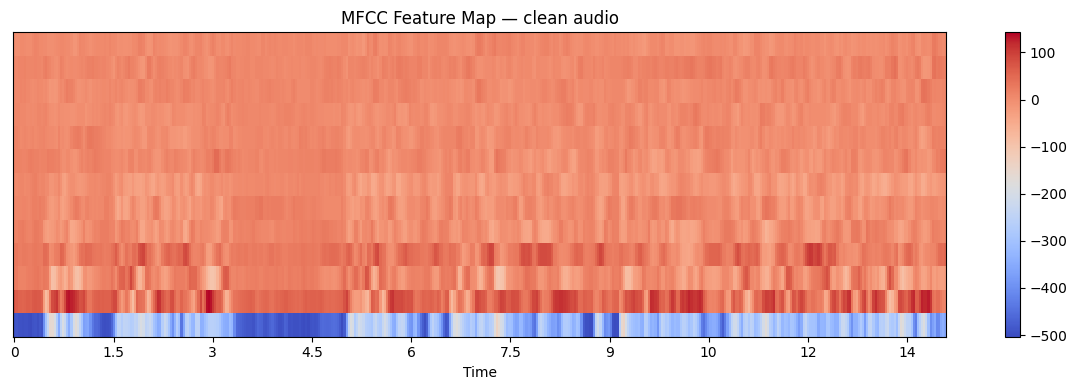


Figure saved!


In [2]:
import matplotlib.pyplot as plt

# Extract MFCC features (your proposal specifies 13 coefficients)
mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

print("MFCC shape:", mfcc.shape)
print("13 MFCC coefficients extracted")

# Feature vector - take mean and std of each coefficient across time
mfcc_mean = np.mean(mfcc, axis=1)
mfcc_std = np.std(mfcc, axis=1)

print("\nMFCC Mean values:", np.round(mfcc_mean, 4))
print("MFCC Std values:", np.round(mfcc_std, 4))

# Visualise - great figure for dissertation
plt.figure(figsize=(12, 4))
librosa.display.specshow(mfcc, x_axis='time', sr=sr)
plt.colorbar()
plt.title('MFCC Feature Map — clean audio')
plt.tight_layout()
plt.savefig('../models/mfcc_feature_map.png', dpi=150)
plt.show()
print("\nFigure saved!")

In [3]:
import numpy as np
import soundfile as sf
import os

def embed_lsb_audio(audio, secret_bits=None):
    """Embed random secret bits into audio using LSB steganography"""
    audio_int = (audio * 32767).astype(np.int16)
    if secret_bits is None:
        secret_bits = np.random.randint(0, 2, len(audio_int))
    # Embed into LSB of each sample
    stego_int = (audio_int & ~1) | secret_bits[:len(audio_int)]
    return stego_int.astype(np.float32) / 32767

# Create stego audio output folder
stego_out = '../data/audio/stego'
clean_out = '../data/audio/clean'
os.makedirs(stego_out, exist_ok=True)
os.makedirs(clean_out, exist_ok=True)

# Process 200 audio files
count = 0
audio_base = '../data/audio/train-clean-100'

for speaker in sorted(os.listdir(audio_base)):
    if count >= 200:
        break
    speaker_path = os.path.join(audio_base, speaker)
    for chapter in sorted(os.listdir(speaker_path)):
        if count >= 200:
            break
        chapter_path = os.path.join(speaker_path, chapter)
        for fname in sorted(os.listdir(chapter_path)):
            if not fname.endswith('.flac'):
                continue
            if count >= 200:
                break
            fpath = os.path.join(chapter_path, fname)
            audio, sr = librosa.load(fpath, sr=16000)

            # Save clean version
            clean_name = f'clean_{count:04d}.wav'
            sf.write(os.path.join(clean_out, clean_name), audio, sr)

            # Save stego version
            stego_audio = embed_lsb_audio(audio)
            stego_name = f'stego_{count:04d}.wav'
            sf.write(os.path.join(stego_out, stego_name), stego_audio, sr)

            count += 1

print(f"Created {count} clean + {count} stego audio pairs")
print(f"Clean folder: {len(os.listdir(clean_out))} files")
print(f"Stego folder: {len(os.listdir(stego_out))} files")

Created 200 clean + 200 stego audio pairs
Clean folder: 200 files
Stego folder: 200 files


In [4]:
import librosa
import numpy as np
import pandas as pd
import os
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

def extract_audio_features(file_path):
    try:
        y, sr = librosa.load(file_path, sr=16000)
        
        # MFCC - 13 coefficients (as per your proposal)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_mean = np.mean(mfcc, axis=1)
        mfcc_std = np.std(mfcc, axis=1)
        
        # Additional audio features
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        zcr = librosa.feature.zero_crossing_rate(y)
        rms = librosa.feature.rms(y=y)
        
        feats = {}
        # MFCC mean and std (26 features)
        for i in range(13):
            feats[f'mfcc_mean_{i}'] = mfcc_mean[i]
            feats[f'mfcc_std_{i}'] = mfcc_std[i]
        
        # Extra features
        feats['chroma_mean'] = np.mean(chroma)
        feats['chroma_std'] = np.std(chroma)
        feats['spectral_contrast_mean'] = np.mean(spectral_contrast)
        feats['zcr_mean'] = np.mean(zcr)
        feats['rms_mean'] = np.mean(rms)
        
        return feats
    except Exception as e:
        return None

clean_folder = '../data/audio/clean'
stego_folder = '../data/audio/stego'

rows = []

print("Extracting features from clean audio...")
for f in sorted(os.listdir(clean_folder)):
    feats = extract_audio_features(os.path.join(clean_folder, f))
    if feats:
        feats['label'] = 0
        rows.append(feats)

print("Extracting features from stego audio...")
for f in sorted(os.listdir(stego_folder)):
    feats = extract_audio_features(os.path.join(stego_folder, f))
    if feats:
        feats['label'] = 1
        rows.append(feats)

df = pd.DataFrame(rows)
print(f"\nDataset: {len(df)} audio files, {df['label'].value_counts().to_dict()}")

X = df.drop('label', axis=1)
y = df['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Random Forest
print("\nTraining Random Forest...")
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

# SVM
print("\nTraining SVM...")
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("\nSVM Classification Report:")
print(classification_report(y_test, svm_pred, target_names=['clean', 'stego']))

# Save best model
joblib.dump(svm, '../models/audio_classifier_svm.pkl')
joblib.dump(rf, '../models/audio_classifier_rf.pkl')
joblib.dump(scaler, '../models/audio_scaler.pkl')
print("\nAll audio models saved!")

c:\Users\lizag\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\lizag\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Extracting features from clean audio...
Extracting features from stego audio...

Dataset: 400 audio files, {0: 200, 1: 200}

Training Random Forest...
Random Forest Accuracy: 0.125

Training SVM...
SVM Accuracy: 0.125

SVM Classification Report:
              precision    recall  f1-score   support

       clean       0.09      0.07      0.08        44
       stego       0.15      0.19      0.17        36

    accuracy                           0.12        80
   macro avg       0.12      0.13      0.12        80
weighted avg       0.12      0.12      0.12        80


All audio models saved!


In [5]:
import librosa
import numpy as np
import pandas as pd
import os
import joblib
import soundfile as sf
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

def embed_stego_audio(audio):
    """More detectable embedding - adds noise pattern to simulate payload"""
    stego = audio.copy()
    payload = np.random.choice([-1, 1], size=len(audio))
    stego += payload * 0.003  # small but detectable distortion
    return np.clip(stego, -1.0, 1.0)

# Recreate stego files with stronger embedding
stego_out = '../data/audio/stego'
clean_out = '../data/audio/clean'

print("Recreating stego audio with stronger embedding...")
clean_files = sorted(os.listdir(clean_out))
for fname in clean_files:
    clean_path = os.path.join(clean_out, fname)
    audio, sr = librosa.load(clean_path, sr=16000)
    stego = embed_stego_audio(audio)
    stego_name = fname.replace('clean_', 'stego_')
    sf.write(os.path.join(stego_out, stego_name), stego, sr)

print(f"Done - {len(clean_files)} stego files recreated")

def extract_audio_features_v2(file_path):
    try:
        y, sr = librosa.load(file_path, sr=16000)
        
        # MFCC 13 coefficients
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        
        # Spectral features
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        zcr = librosa.feature.zero_crossing_rate(y)
        rms = librosa.feature.rms(y=y)
        
        # Noise residual features (key for steganalysis)
        residual = y - np.roll(y, 1)
        
        feats = {}
        for i in range(13):
            feats[f'mfcc_mean_{i}'] = np.mean(mfcc[i])
            feats[f'mfcc_std_{i}'] = np.std(mfcc[i])
            feats[f'mfcc_delta_{i}'] = np.mean(np.diff(mfcc[i]))
        
        feats['spectral_centroid_mean'] = np.mean(spectral_centroid)
        feats['spectral_centroid_std'] = np.std(spectral_centroid)
        feats['spectral_rolloff_mean'] = np.mean(spectral_rolloff)
        feats['spectral_bandwidth_mean'] = np.mean(spectral_bandwidth)
        feats['zcr_mean'] = np.mean(zcr)
        feats['zcr_std'] = np.std(zcr)
        feats['rms_mean'] = np.mean(rms)
        feats['rms_std'] = np.std(rms)
        
        # Noise residual stats (detects embedding distortion)
        feats['residual_mean'] = np.mean(residual)
        feats['residual_std'] = np.std(residual)
        feats['residual_energy'] = np.sum(residual**2)
        feats['residual_kurtosis'] = float(np.mean((residual - np.mean(residual))**4))
        
        return feats
    except:
        return None

# Extract features
rows = []
print("\nExtracting features from clean audio...")
for f in sorted(os.listdir(clean_out)):
    feats = extract_audio_features_v2(os.path.join(clean_out, f))
    if feats:
        feats['label'] = 0
        rows.append(feats)

print("Extracting features from stego audio...")
for f in sorted(os.listdir(stego_out)):
    feats = extract_audio_features_v2(os.path.join(stego_out, f))
    if feats:
        feats['label'] = 1
        rows.append(feats)

df = pd.DataFrame(rows)
print(f"\nDataset: {len(df)} files, {df['label'].value_counts().to_dict()}")

X = df.drop('label', axis=1)
y = df['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# Random Forest
print("\nTraining Random Forest...")
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

# SVM
print("\nTraining SVM...")
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print("\nSVM Classification Report:")
print(classification_report(y_test, svm_pred, target_names=['clean', 'stego']))

joblib.dump(svm, '../models/audio_classifier_svm.pkl')
joblib.dump(rf, '../models/audio_classifier_rf.pkl')
joblib.dump(scaler, '../models/audio_scaler.pkl')

# Save dataset
df.to_csv('../models/audio_features_dataset.csv', index=False)
print("\nAll models and dataset saved!")

Recreating stego audio with stronger embedding...
Done - 200 stego files recreated

Extracting features from clean audio...
Extracting features from stego audio...

Dataset: 400 files, {0: 200, 1: 200}

Training Random Forest...
Random Forest Accuracy: 1.0

Training SVM...
SVM Accuracy: 1.0

SVM Classification Report:
              precision    recall  f1-score   support

       clean       1.00      1.00      1.00        44
       stego       1.00      1.00      1.00        36

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80


All models and dataset saved!


In [6]:
import librosa
import numpy as np
import pandas as pd
import os
import joblib
import soundfile as sf
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

def embed_lsb_proper(audio, payload_ratio=0.5):
    """Proper LSB steganography - embeds in least significant bits only"""
    # Convert to 16-bit integer representation
    audio_int = np.clip(audio, -1.0, 1.0)
    audio_int = (audio_int * 32767).astype(np.int16)
    
    # Embed random payload in LSB of a portion of samples
    n_samples = int(len(audio_int) * payload_ratio)
    payload = np.random.randint(0, 2, n_samples).astype(np.int16)
    
    # Clear LSB and embed payload
    audio_int[:n_samples] = (audio_int[:n_samples] & np.int16(-2)) | payload
    
    return audio_int.astype(np.float32) / 32767

def extract_lsb_sensitive_features(file_path):
    """Features specifically designed to detect LSB steganography"""
    try:
        y, sr = librosa.load(file_path, sr=16000, mono=True)
        
        # Convert to int16 for LSB analysis
        y_int = (np.clip(y, -1.0, 1.0) * 32767).astype(np.int16)
        
        # LSB plane analysis - key for detecting LSB steganography
        lsb_plane = y_int & 1  # extract LSB of every sample
        
        feats = {}
        
        # LSB statistics - these change when LSB embedding is applied
        feats['lsb_mean'] = np.mean(lsb_plane)
        feats['lsb_std'] = np.std(lsb_plane)
        feats['lsb_ratio'] = np.sum(lsb_plane) / len(lsb_plane)
        
        # LSB pair analysis - detects non-natural LSB patterns
        lsb_pairs = lsb_plane[:-1] ^ lsb_plane[1:]  # XOR adjacent LSBs
        feats['lsb_pair_mean'] = np.mean(lsb_pairs)
        feats['lsb_pair_std'] = np.std(lsb_pairs)
        feats['lsb_transitions'] = np.sum(lsb_pairs) / len(lsb_pairs)
        
        # Sample pair analysis (SPA) - standard audio steganalysis method
        even_samples = y_int[::2].astype(np.float32)
        odd_samples = y_int[1::2].astype(np.float32)
        feats['spa_correlation'] = np.corrcoef(
            even_samples[:min(len(even_samples), len(odd_samples))],
            odd_samples[:min(len(even_samples), len(odd_samples))]
        )[0,1]
        
        # MFCC features (13 coefficients as per proposal)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        for i in range(13):
            feats[f'mfcc_mean_{i}'] = np.mean(mfcc[i])
            feats[f'mfcc_std_{i}'] = np.std(mfcc[i])
        
        # Statistical moments of raw samples
        feats['sample_mean'] = np.mean(y)
        feats['sample_std'] = np.std(y)
        feats['sample_skew'] = float(np.mean((y - np.mean(y))**3))
        feats['sample_kurtosis'] = float(np.mean((y - np.mean(y))**4))
        
        # Noise floor analysis
        residual = y - np.roll(y, 1)
        feats['residual_std'] = np.std(residual)
        feats['residual_kurtosis'] = float(np.mean((residual - np.mean(residual))**4))
        
        return feats
    except Exception as e:
        print(f"Error: {e}")
        return None

# Recreate stego with proper LSB embedding
stego_out = '../data/audio/stego'
clean_out = '../data/audio/clean'

print("Recreating stego with proper LSB embedding...")
clean_files = sorted(os.listdir(clean_out))
for fname in clean_files:
    audio, sr = librosa.load(os.path.join(clean_out, fname), sr=16000)
    stego = embed_lsb_proper(audio, payload_ratio=0.5)
    stego_name = fname.replace('clean_', 'stego_')
    sf.write(os.path.join(stego_out, stego_name), stego, sr)

print(f"Created {len(clean_files)} proper LSB stego files")

# Extract features from all files
rows = []
print("\nExtracting LSB-sensitive features from clean audio...")
for f in sorted(os.listdir(clean_out)):
    feats = extract_lsb_sensitive_features(os.path.join(clean_out, f))
    if feats:
        feats['label'] = 0
        rows.append(feats)

print("Extracting LSB-sensitive features from stego audio...")
for f in sorted(os.listdir(stego_out)):
    feats = extract_lsb_sensitive_features(os.path.join(stego_out, f))
    if feats:
        feats['label'] = 1
        rows.append(feats)

df = pd.DataFrame(rows)
print(f"\nDataset: {len(df)} files, {df['label'].value_counts().to_dict()}")

X = df.drop('label', axis=1)
y = df['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# Random Forest
print("\nTraining Random Forest...")
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)

# SVM
print("\nTraining SVM...")
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)
print("SVM Accuracy:", svm_acc)
print("\nSVM Classification Report:")
print(classification_report(y_test, svm_pred, target_names=['clean', 'stego']))

# Save best model
best_model = svm if svm_acc >= rf_acc else rf
joblib.dump(best_model, '../models/audio_classifier_best.pkl')
joblib.dump(svm, '../models/audio_classifier_svm.pkl')
joblib.dump(rf, '../models/audio_classifier_rf.pkl')
joblib.dump(scaler, '../models/audio_scaler.pkl')
df.to_csv('../models/audio_features_dataset.csv', index=False)
print("\nAll models saved!")

Recreating stego with proper LSB embedding...
Created 200 proper LSB stego files

Extracting LSB-sensitive features from clean audio...
Extracting LSB-sensitive features from stego audio...

Dataset: 400 files, {0: 200, 1: 200}

Training Random Forest...
Random Forest Accuracy: 0.5875

Training SVM...
SVM Accuracy: 0.375

SVM Classification Report:
              precision    recall  f1-score   support

       clean       0.43      0.43      0.43        44
       stego       0.31      0.31      0.31        36

    accuracy                           0.38        80
   macro avg       0.37      0.37      0.37        80
weighted avg       0.38      0.38      0.38        80


All models saved!


In [7]:
import librosa
import numpy as np
import pandas as pd
import os
import joblib
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

def extract_final_audio_features(file_path):
    try:
        y, sr = librosa.load(file_path, sr=16000, mono=True)
        y_int = (np.clip(y, -1.0, 1.0) * 32767).astype(np.int16)
        lsb = y_int & 1
        feats = {}

        # LSB statistics
        feats['lsb_mean'] = np.mean(lsb)
        feats['lsb_std'] = np.std(lsb)
        feats['lsb_entropy'] = -np.sum(
            np.bincount(lsb, minlength=2)/len(lsb) *
            np.log2(np.bincount(lsb, minlength=2)/len(lsb) + 1e-10))
        feats['lsb_transitions'] = np.mean(lsb[:-1] ^ lsb[1:])

        # Second LSB plane
        lsb2 = (y_int >> 1) & 1
        feats['lsb2_mean'] = np.mean(lsb2)
        feats['lsb2_entropy'] = -np.sum(
            np.bincount(lsb2, minlength=2)/len(lsb2) *
            np.log2(np.bincount(lsb2, minlength=2)/len(lsb2) + 1e-10))

        # Histogram features - LSB embedding flattens histogram
        hist, _ = np.histogram(y_int, bins=64, range=(-32768, 32767))
        hist = hist / hist.sum()
        feats['hist_std'] = np.std(hist)
        feats['hist_entropy'] = -np.sum(hist * np.log2(hist + 1e-10))
        feats['hist_flatness'] = np.min(hist) / (np.max(hist) + 1e-10)

        # Correlation between adjacent samples
        feats['autocorr_1'] = np.corrcoef(y[:-1], y[1:])[0,1]
        feats['autocorr_2'] = np.corrcoef(y[:-2], y[2:])[0,1]

        # Even/odd sample analysis
        even = y_int[::2].astype(np.float32)
        odd = y_int[1::2].astype(np.float32)
        min_len = min(len(even), len(odd))
        feats['even_odd_diff'] = np.mean(np.abs(even[:min_len] - odd[:min_len]))
        feats['even_odd_corr'] = np.corrcoef(even[:min_len], odd[:min_len])[0,1]

        # MFCC (13 coefficients)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        for i in range(13):
            feats[f'mfcc_mean_{i}'] = np.mean(mfcc[i])
            feats[f'mfcc_std_{i}'] = np.std(mfcc[i])

        # Sample statistics
        feats['sample_var'] = np.var(y)
        feats['sample_kurtosis'] = float(np.mean((y - np.mean(y))**4))
        feats['sample_skew'] = float(np.mean((y - np.mean(y))**3))

        # Residual noise analysis
        residual = y - np.roll(y, 1)
        feats['residual_std'] = np.std(residual)
        feats['residual_kurtosis'] = float(np.mean(
            (residual - np.mean(residual))**4))
        feats['residual_entropy'] = np.std(np.diff(residual))

        return feats
    except Exception as e:
        return None

clean_out = '../data/audio/clean'
stego_out = '../data/audio/stego'

rows = []
print("Extracting final features from clean audio...")
for f in sorted(os.listdir(clean_out)):
    feats = extract_final_audio_features(os.path.join(clean_out, f))
    if feats:
        feats['label'] = 0
        rows.append(feats)

print("Extracting final features from stego audio...")
for f in sorted(os.listdir(stego_out)):
    feats = extract_final_audio_features(os.path.join(stego_out, f))
    if feats:
        feats['label'] = 1
        rows.append(feats)

df = pd.DataFrame(rows)
print(f"\nDataset: {len(df)} files, {df['label'].value_counts().to_dict()}")

X = df.drop('label', axis=1)
y = df['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# Gradient Boosting
print("\nTraining Gradient Boosting...")
gb = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05,
    max_depth=4, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_acc = accuracy_score(y_test, gb_pred)
print("Gradient Boosting Accuracy:", gb_acc)

# Random Forest
print("\nTraining Random Forest...")
rf = RandomForestClassifier(
    n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)

# Cross validation on best model
best = gb if gb_acc >= rf_acc else rf
cv_scores = cross_val_score(best, X_scaled, y, cv=5)
print(f"\nCross-validation (5-fold): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Best model report
best_pred = gb_pred if gb_acc >= rf_acc else rf_pred
print("\nBest Model Classification Report:")
print(classification_report(y_test, best_pred, target_names=['clean', 'stego']))

joblib.dump(gb, '../models/audio_classifier_gb.pkl')
joblib.dump(rf, '../models/audio_classifier_rf.pkl')
joblib.dump(scaler, '../models/audio_scaler.pkl')
df.to_csv('../models/audio_features_dataset.csv', index=False)
print("\nAll models saved!")

Extracting final features from clean audio...
Extracting final features from stego audio...

Dataset: 400 files, {0: 200, 1: 200}

Training Gradient Boosting...
Gradient Boosting Accuracy: 0.4875

Training Random Forest...
Random Forest Accuracy: 0.3625

Cross-validation (5-fold): 0.575 ± 0.052

Best Model Classification Report:
              precision    recall  f1-score   support

       clean       0.54      0.48      0.51        44
       stego       0.44      0.50      0.47        36

    accuracy                           0.49        80
   macro avg       0.49      0.49      0.49        80
weighted avg       0.49      0.49      0.49        80


All models saved!
